<a href="https://colab.research.google.com/github/slimisgit/grokking/blob/tests_core/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

статья: [url text](https://www.lesswrong.com/posts/bTgTggoKRGLRF4enD/grokking-revisited-reverse-engineering-grokking-modulo)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt  # графики
import numpy as np
import os
from dataclasses import dataclass, asdict
import json
from google.colab import userdata


# создание дата сета
def create_dataset(N, fraction_train, seed=42):
    np.random.seed(seed)
    all_pairs = [(x, y) for x in range(N) for y in range(N)]
    np.random.shuffle(all_pairs)
    all_pairs = np.array(all_pairs)

    total_size = len(all_pairs)
    train_size = int(total_size * fraction_train)
    test_size = total_size - train_size

    train_pairs = all_pairs[:train_size]
    test_pairs = all_pairs[train_size:]

    def pairs_to_dataset(pairs):
        xs = torch.tensor(pairs[:, 0], dtype=torch.long)
        ys = torch.tensor(pairs[:, 1], dtype=torch.long)
        targets = (xs + ys) % N
        return xs, ys, targets

    train_x, train_y, train_t = pairs_to_dataset(train_pairs)
    test_x, test_y, test_t = pairs_to_dataset(test_pairs)
    train_seq = torch.stack([train_x, train_y], dim=1)
    train_targets = train_t
    test_seq = torch.stack([test_x, test_y], dim=1)
    test_targets = test_t

    return train_seq, train_targets, test_seq, test_targets


# модель
class LSTMModelOneHot(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(LSTMModelOneHot, self).__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size

        self.W_ih = nn.Linear(vocab_size, 4 * hidden_size, bias=True)  # это типо 4 матрицы в одной для скорости
        self.W_hh = nn.Linear(hidden_size, 4 * hidden_size, bias=True)
        self.fc1 = nn.Linear(hidden_size, vocab_size, bias=False)

    # один шаг по времени(вообще по времени в батче,но у нас батч=эпоха)
    def forward(self, x_seq):
        batch_size, seq_len = x_seq.size()
        device = x_seq.device

        # представление батча в onehot
        x_onehot = torch.zeros(batch_size, seq_len, self.vocab_size, device=device)
        x_onehot.scatter_(2, x_seq.unsqueeze(2), 1)

        # начальные долгосрочная и короткосрочная память
        h = torch.zeros(batch_size, self.hidden_size, device=device)
        c = torch.zeros(batch_size, self.hidden_size, device=device)

        for t in range(seq_len):
            # типо времени в LSTM (тут или 0 или 1)
            x_t = x_onehot[:, t, :]

            # логика LSTM,но т.к матрицы склеены в одну читать невозможно
            gates = self.W_ih(x_t) + self.W_hh(h)
            i = torch.sigmoid(gates[:, 0:self.hidden_size])  # input gate
            f = torch.sigmoid(gates[:, self.hidden_size:2 * self.hidden_size])  # forget gate
            g = torch.tanh(gates[:, 2 * self.hidden_size:3 * self.hidden_size])  # candidate gate
            o = torch.sigmoid(gates[:, 3 * self.hidden_size:4 * self.hidden_size])  # output gate

            # логика долгосрочной памяти
            c = f * c + i * g

            h = torch.tanh(c) * o  #

        logits = self.fc1(h)

        return logits


In [12]:
# класс хранящий данные о том как отработала модель
@dataclass
class Grokking_Data:
    seed: int

    train_losses: list
    train_accuracies: list
    test_losses: list
    test_accuracies: list

    hidden_size_ratio: float = 1.0
    N: int = 113
    fraction_train: float = 0.3
    lr: float = 1e-3
    weight_decay: float = 1.0
    beta1: float = 0.9
    beta2: float = 0.98
    epochs: int = 100000
    checkpoint_interval: int = 200

    # характеристики гроккинга
    first_train_high_acc_epoch: int = -1
    first_test_high_acc_epoch: int = -1
    test_loss_peak_epoch: int = -1
    first_sustained_test_acc_epoch: int = -1
    test_loss_peak: float = -1.0
    grokking: bool = False
    plate_length: int = 0

    weights_path: str = ""

    def save(self, folder="results", model=None):

        os.makedirs(folder, exist_ok=True)
        parts = [f"seed{self.seed}"]

        # в нейминге гиперпараметр который отличается от дефолта
        defaults = {
            "N": 113, "fraction_train": 0.3, "lr": 1e-3,
            "weight_decay": 1.0, "epochs": 100000, "beta1": 0.9, "beta2": 0.98,
            "hidden_size_ratio": 1.0
        }

        for param, default in defaults.items():
            value = getattr(self, param)
            if value != default:
                parts.append(f"{param}{value:g}")

        filename = f"{folder}/{'__'.join(parts)}.json"

        # на всякий случай веса модели сохраняем(путь до них)
        if model is not None:
            self.weights_path = f"{folder}/{'__'.join(parts)}_model.pt"
            torch.save(model.state_dict(), self.weights_path)

        with open(filename, 'w') as f:
            json.dump(asdict(self), f)
        print(f"Saved to {filename}")

    @classmethod
    def load(cls, filename):
        with open(filename, 'r') as f:
            data = json.load(f)

        return cls(**data)


# функция обучения
def train_and_test_with_params(seed: int, N=113,
                               fraction_train=0.3,
                               lr=1e-3,
                               weight_decay=1.0,
                               beta1=0.9,
                               beta2=0.98,
                               epochs=100000,
                               checkpoint_interval=200,
                               hidden_size_ratio=1.0) -> Grokking_Data:
    # установка сида рандома + рандом
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_seq, train_targets, test_seq, test_targets = create_dataset(N, fraction_train, seed)

    # сама модель
    model = LSTMModelOneHot(N, int(N * hidden_size_ratio))
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(beta1, beta2))
    criterion = nn.CrossEntropyLoss()  # функция loss

    # подсчет точности модели
    def evaluate(model, x_seq, targets, batch_size=512):
        model.eval()  # не обучаемся
        correct = 0
        total = 0
        with torch.no_grad():  # не обучаемся
            for start in range(0, len(x_seq), batch_size):
                end = min(start + batch_size, len(x_seq))
                batch_seq = x_seq[start:end].to(next(model.parameters()).device)
                batch_t = targets[start:end].to(next(model.parameters()).device)
                logits = model(batch_seq)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch_t).sum().item()
                total += (end - start)
        return correct / total

    # подсчет функции потерь с усреднением по батчу
    def full_loss(model, x_seq, targets, batch_size=512):
        model.eval()
        total_loss = 0.0
        count = 0
        with torch.no_grad():
            for start in range(0, len(x_seq), batch_size):
                end = min(start + batch_size, len(x_seq))
                batch_seq = x_seq[start:end].to(next(model.parameters()).device)
                batch_t = targets[start:end].to(next(model.parameters()).device)
                logits = model(batch_seq)
                loss = criterion(logits, batch_t)
                total_loss += loss.item() * (end - start)
                count += (end - start)
        return total_loss / count

    # обучение модели
    # перенос всего на ускоритель,если возможно
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    train_seq = train_seq.to(device)
    train_targets = train_targets.to(device)
    test_seq = test_seq.to(device)
    test_targets = test_targets.to(device)

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    test_loss_peak_epoch = 0
    test_loss_peak = -1
    first_train_high_acc_epoch = -1
    first_test_high_acc_epoch = -1
    first_sustained_test_acc_epoch = -1
    grokking = False
    plate_length = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()  # градиенты иначе будут складываться между эпохами(т.к они вроде локально сопоставлены торчам)
        logits = model(train_seq)
        loss = criterion(logits, train_targets)
        loss.backward()
        optimizer.step()

        # данные для логов
        if (epoch % checkpoint_interval == 0) or (epoch == epochs - 1):
            train_loss = full_loss(model, train_seq, train_targets)
            test_loss = full_loss(model, test_seq, test_targets)
            train_acc = evaluate(model, train_seq, train_targets)
            test_acc = evaluate(model, test_seq, test_targets)

            # обновляем максимум лосса
            if test_loss > test_loss_peak:
                test_loss_peak_epoch = epoch
                test_loss_peak = test_loss

            # считаем конец и начало плато
            if first_train_high_acc_epoch == -1 and train_acc > 0.9:
                first_train_high_acc_epoch = epoch

            if first_test_high_acc_epoch == -1 and test_acc > 0.9:
                first_test_high_acc_epoch = epoch

            train_losses.append((epoch, train_loss))
            test_losses.append((epoch, test_loss))
            train_accuracies.append((epoch, train_acc))
            test_accuracies.append((epoch, test_acc))

            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, "
                  f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

    # момент когда тест аккураси начало расти
    # момент когда тест аккураси начало расти (ПОСЛЕ first_train_high)
    THRESHOLD = 0.05
    K = 3

    if first_train_high_acc_epoch != -1:
        # Находим индекс, соответствующий first_train_high
        start_idx = 0
        for i, (epoch, _) in enumerate(test_accuracies):
            if epoch >= first_train_high_acc_epoch:
                start_idx = i
                break

        # Ищем окно из K точек, где все > threshold
        for i in range(start_idx, len(test_accuracies) - K + 1):
            ok = True
            for j in range(K):
                _, acc = test_accuracies[i + j]
                if acc <= THRESHOLD:  # всё ещё низкая точность
                    ok = False
                    break
            if ok:
                first_sustained_test_acc_epoch = test_accuracies[i][0]
                break

    # длинна плато
    if (
            first_train_high_acc_epoch != -1
            and first_sustained_test_acc_epoch != -1
    ):
        plate_length = first_sustained_test_acc_epoch - first_train_high_acc_epoch
    else:
        plate_length = -1

    plate_length = max(-1, plate_length)

    if plate_length > 400 and first_test_high_acc_epoch != -1 and first_train_high_acc_epoch != -1:
        grokking = True

    result = Grokking_Data(
        seed=seed,
        train_losses=train_losses,
        train_accuracies=train_accuracies,
        test_losses=test_losses,
        test_accuracies=test_accuracies,
        hidden_size_ratio=hidden_size_ratio,
        N=N,
        fraction_train=fraction_train,
        lr=lr,
        weight_decay=weight_decay,
        beta1=beta1,
        beta2=beta2,
        epochs=epochs,
        checkpoint_interval=checkpoint_interval,
        first_train_high_acc_epoch=first_train_high_acc_epoch,
        first_test_high_acc_epoch=first_test_high_acc_epoch,
        test_loss_peak_epoch=test_loss_peak_epoch,
        first_sustained_test_acc_epoch=first_sustained_test_acc_epoch,
        test_loss_peak=test_loss_peak,
        grokking=grokking,
        plate_length=plate_length
    )

    result.save(model=model)

    return result


# отрисовка графиков
def graphic(train_losses, train_accuracies, test_losses, test_accuracies):
    epochs_logged = [e for e, _ in train_losses]
    train_loss_vals = [l for _, l in train_losses]
    test_loss_vals = [l for _, l in test_losses]
    train_acc_vals = [a for _, a in train_accuracies]
    test_acc_vals = [a for _, a in test_accuracies]

    plt.figure(figsize=(14, 10))

    # верхний левый — Loss (обычный)
    plt.subplot(2, 2, 1)
    plt.plot(epochs_logged, train_loss_vals, label='Train Loss')
    plt.plot(epochs_logged, test_loss_vals, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Time')
    plt.legend()

    # верхний правый — Accuracy (обычный)
    plt.subplot(2, 2, 2)
    plt.plot(epochs_logged, train_acc_vals, label='Train Acc')
    plt.plot(epochs_logged, test_acc_vals, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Time')
    plt.legend()

    # нижний левый — Loss (log-log)
    plt.subplot(2, 2, 3)
    plt.loglog(epochs_logged, train_loss_vals, label='Train Loss')
    plt.loglog(epochs_logged, test_loss_vals, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Time (Log-Log)')
    plt.legend()

    # нижний правый — Accuracy (log-log)
    plt.subplot(2, 2, 4)
    plt.loglog(epochs_logged, train_acc_vals, label='Train Acc')
    plt.loglog(epochs_logged, test_acc_vals, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Time (Log-Log)')
    plt.legend()

    plt.tight_layout()
    plt.show()



In [1]:
#запускаете 1 раз в начале сессии
from google.colab import userdata
import os

token = userdata.get('GH_TOKEN')
repo_url = f"https://{token}@github.com/slimisgit/grokking.git"

if not os.path.exists('/content/grokking'):
    !git clone {repo_url}

%cd /content/grokking

!git switch tests_core
!git config user.email "slimismission@gmail.com"
!git config user.name "slimisgit"

!git remote set-url origin https://{token}@github.com/slimisgit/grokking.git

Cloning into 'grokking'...
remote: Enumerating objects: 509, done.
remote: Counting objects: 100% (304/304), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 509 (delta 163), reused 246 (delta 111), pack-reused 205 (from 1)
Receiving objects: 100% (509/509), 28.94 MiB | 14.29 MiB/s, done.
Resolving deltas: 100% (232/232), done.
/content/grokking
Branch 'tests_core' set up to track remote branch 'tests_core' from 'origin'.
Switched to a new branch 'tests_core'


Epoch 0: Train Loss=4.7266, Test Loss=4.7279, Train Acc=0.0089, Test Acc=0.0084
Epoch 100: Train Loss=4.6091, Test Loss=4.8080, Train Acc=0.0222, Test Acc=0.0039
Epoch 200: Train Loss=4.1476, Test Loss=5.2636, Train Acc=0.1076, Test Acc=0.0006
Epoch 300: Train Loss=3.6613, Test Loss=5.9863, Train Acc=0.1266, Test Acc=0.0000
Epoch 400: Train Loss=3.2321, Test Loss=6.7188, Train Acc=0.1608, Test Acc=0.0000
Epoch 500: Train Loss=2.8321, Test Loss=7.4726, Train Acc=0.2300, Test Acc=0.0000
Epoch 600: Train Loss=2.4371, Test Loss=8.2013, Train Acc=0.3830, Test Acc=0.0000
Epoch 700: Train Loss=2.0478, Test Loss=8.8737, Train Acc=0.5838, Test Acc=0.0000
Epoch 800: Train Loss=1.6781, Test Loss=9.4695, Train Acc=0.7470, Test Acc=0.0000
Epoch 900: Train Loss=1.3424, Test Loss=10.0004, Train Acc=0.8856, Test Acc=0.0000
Epoch 1000: Train Loss=1.0471, Test Loss=10.4681, Train Acc=0.9621, Test Acc=0.0000
Epoch 1100: Train Loss=0.7976, Test Loss=10.8929, Train Acc=0.9937, Test Acc=0.0000
Epoch 1200: T

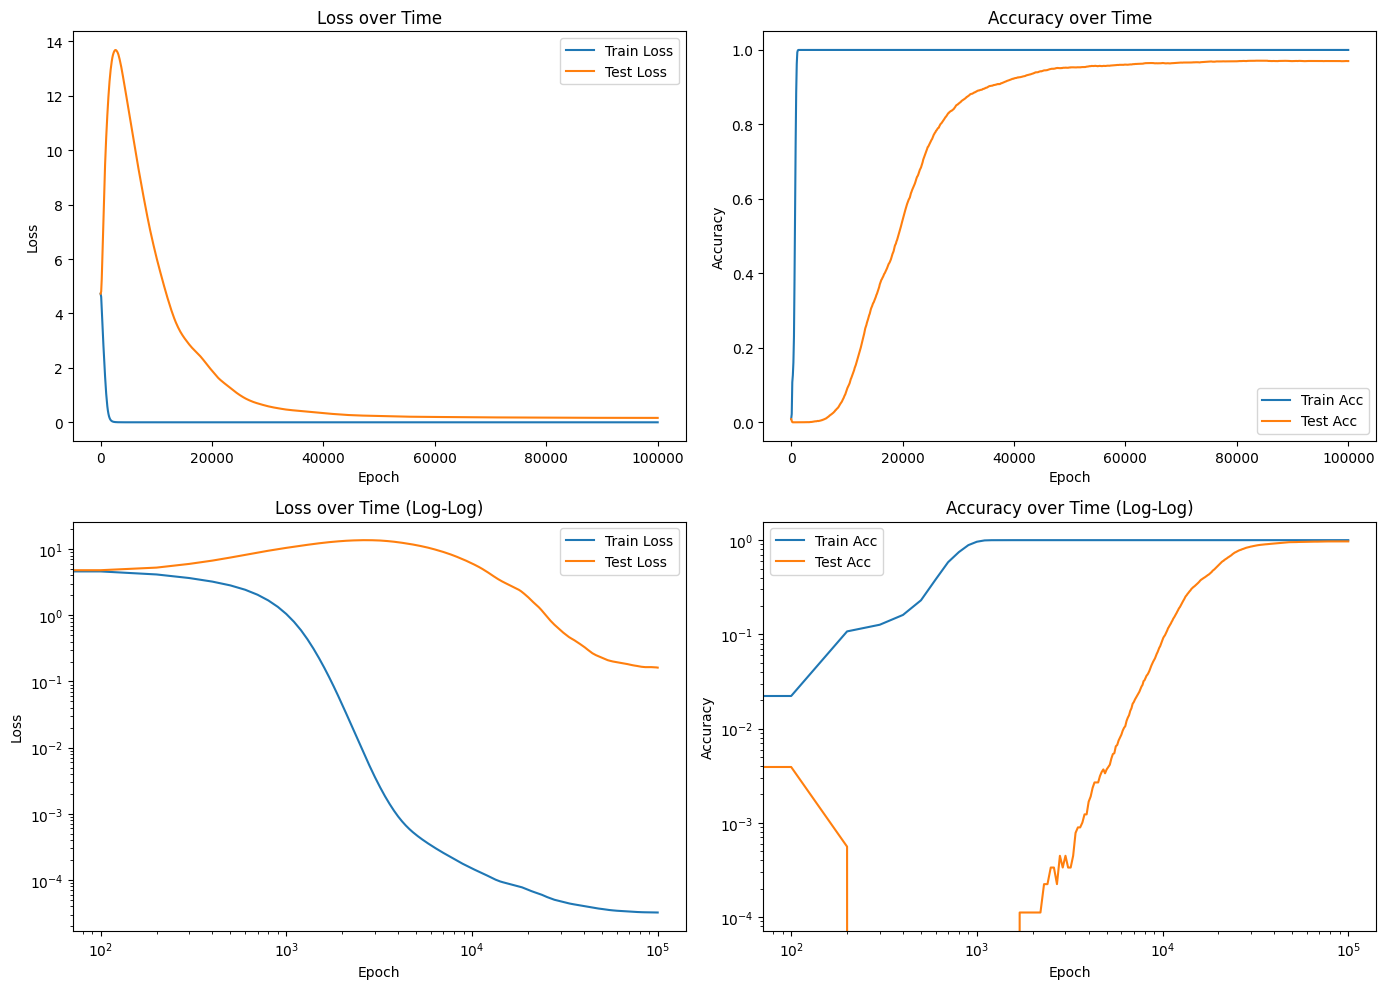

A	results/seed67__beta10.8__beta20.5.json
A	results/seed67__beta10.8__beta20.5_model.pt
Already on 'tests_core'
Your branch is up to date with 'origin/tests_core'.
[tests_core b750ed6] seed=67 beta1=0.8
 2 files changed, 1 insertion(+)
 create mode 100644 results/seed67__beta10.8__beta20.5.json
 create mode 100644 results/seed67__beta10.8__beta20.5_model.pt
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 450.75 KiB | 11.27 MiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/slimisgit/grokking.git
   a6856d3..b750ed6  tests_core -> tests_core


In [16]:
#обучение+тесты (ЛЮБОЙ ЗАПУСК КОМИТИТСЯ)

result = train_and_test_with_params(seed = 67, beta1 = 0.8, beta2 = 0.5, checkpoint_interval = 100)
graphic(result.train_losses, result.train_accuracies, result.test_losses, result.test_accuracies)

!git add results/
!git checkout tests_core
!git commit -m "seed=67 beta1=0.8"
!git push origin tests_core

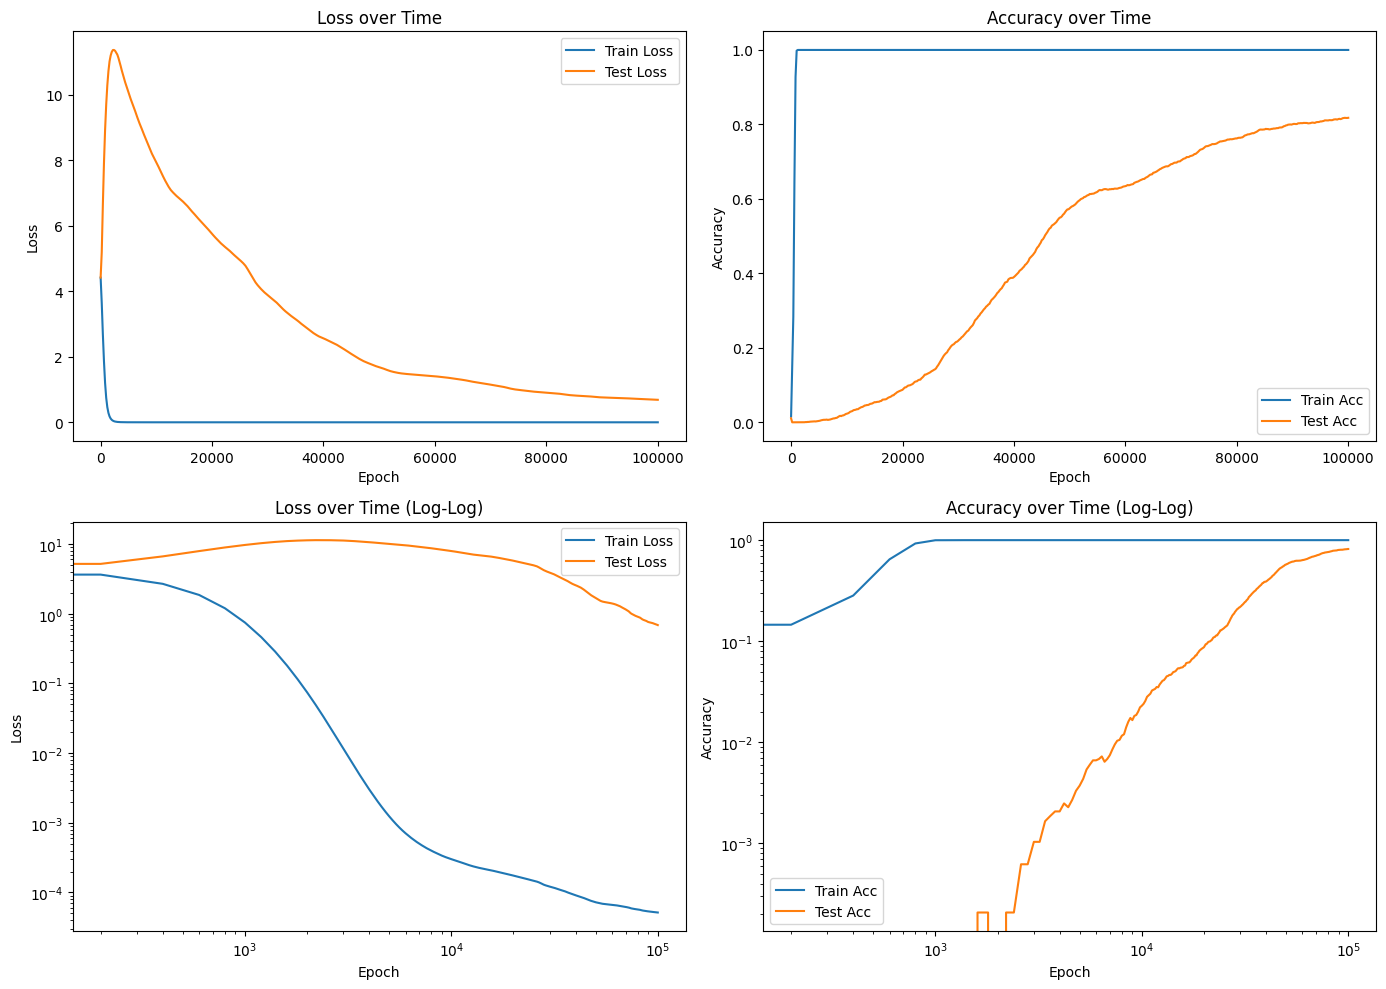

In [9]:
#вывод графиков тестов которые уже были проведены
loaded = Grokking_Data.load("results/seed67__N83.json")

graphic(loaded.train_losses, loaded.train_accuracies, loaded.test_losses, loaded.test_accuracies)

In [3]:
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import json

#функция строящая графики (точка попадает если она есть во всех указанных seed)
def plot_metric_vs_hyperparam(
    hyperparam_name: str,
    seeds: list[int],
    metric_name: str,
    results_dir: str = "results",
):

    results_path = Path(results_dir)
    data_by_seed = defaultdict(dict)

    #тырим все что у нас есть
    for file in results_path.glob("*.json"):

        name = file.stem
        parts = name.split("__")

        #только с одним изменением
        if len(parts) != 2:
            continue

        seed_part, hyper_part = parts

        if not seed_part.startswith("seed"):
            continue

        seed = int(seed_part[len("seed"):])

        if seed not in seeds:
            continue

        if not hyper_part.startswith(hyperparam_name):
            continue

        hyper_value = float(hyper_part[len(hyperparam_name):])

        with open(file, "r") as f:
            data = json.load(f)

        if metric_name not in data:
            continue

        metric_value = float(data[metric_name])

        data_by_seed[seed][hyper_value] = metric_value

    if len(data_by_seed) == 0:
        raise ValueError("Подходящие файлы не найдены")

    #только если есть везде
    common_x = set.intersection(
        *[set(d.keys()) for d in data_by_seed.values()]
    )
    common_x = sorted(common_x)

    if len(common_x) == 0:
        raise ValueError("Нет общих значений hyperparam между seeds")


    means = []
    lower = []
    upper = []

    for x in common_x:

        vals = np.array(
            [data_by_seed[s][x] for s in seeds],
            dtype=float
        )

        mean = vals.mean()

        sigma = np.sqrt((vals ** 2).mean()-mean ** 2)

        means.append(mean)
        lower.append(mean - sigma)
        upper.append(mean + sigma)


    plt.figure(figsize=(10, 6))

    # линии по seed
    for seed in seeds:
        points = sorted(data_by_seed[seed].items())
        xs = [p[0] for p in points if p[0] in common_x]
        ys = [p[1] for p in points if p[0] in common_x]

        plt.plot(xs, ys, alpha=0.4, marker='o', label=f"seed {seed}")

    # mean
    plt.plot(
        common_x,
        means,
        color="black",
        linewidth=3,
        marker="o",
        label="mean"
    )

    # CI
    plt.fill_between(
        common_x,
        lower,
        upper,
        alpha=0.2,
        color="black",
        label="95% CI"
    )

    plt.xlabel(hyperparam_name)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} vs {hyperparam_name} (intersection over seeds)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

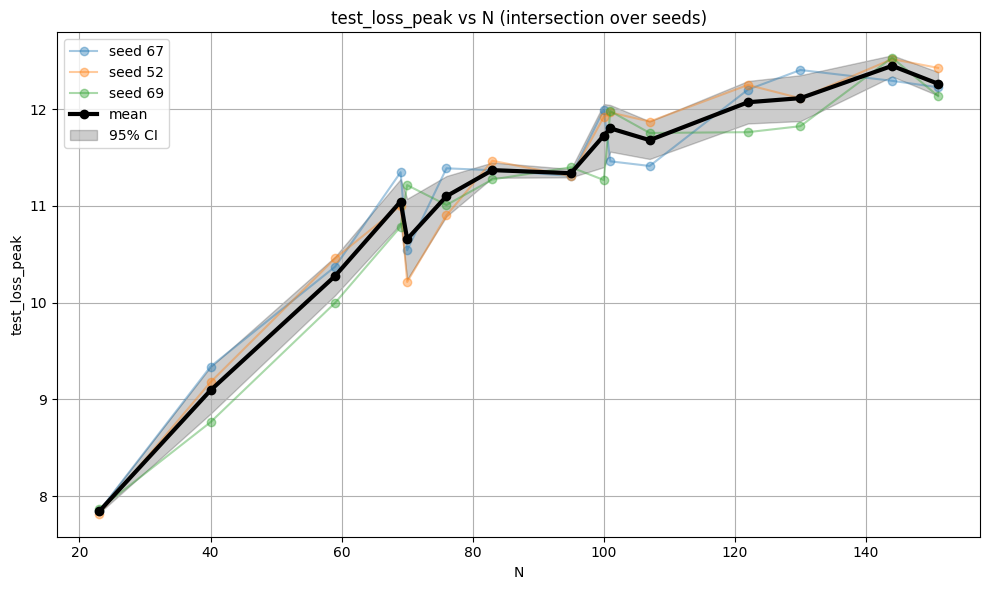

In [14]:
#мега графики газики
plot_metric_vs_hyperparam(
    hyperparam_name="N",
    seeds=[67,52,69],
    metric_name="test_loss_peak"
)